<a href="https://colab.research.google.com/github/ishikabeniwal/CSET343/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA

In [22]:
df = pd.read_csv("diabetes.csv")

print(df.head())
print(df.shape)
print(df.isnull().sum())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [23]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


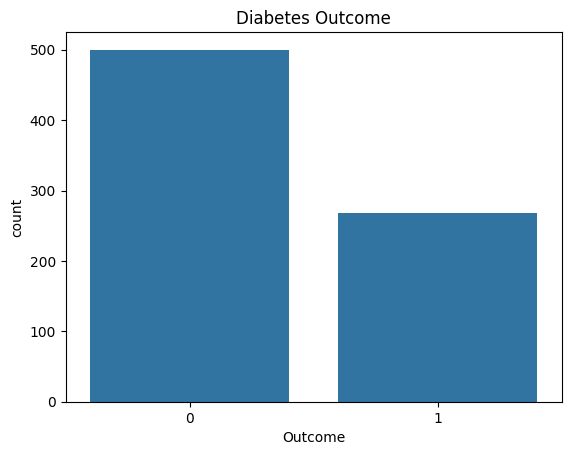

In [24]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome")
plt.show()

In [25]:
diabetic = df[df["Outcome"] == 1]["Glucose"]
non_diabetic = df[df["Outcome"] == 0]["Glucose"]

t_stat, p_value = ttest_ind(diabetic, non_diabetic)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 15.673795182294105
P-value: 3.1287190418423694e-48


In [26]:
df["Glucose_Category"] = pd.cut(
    df["Glucose"],
    bins=[0, 100, 140, 200],
    labels=["Low", "Medium", "High"]
)

table = pd.crosstab(
    df["Glucose_Category"],
    df["Outcome"]
)

chi_stat, p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", chi_stat)
print("P-value:", p_value)

Chi-square: 161.6270075314729
P-value: 8.000944378691123e-36


In [27]:
low = df[df["BMI"] < 25]["Glucose"]

medium = df[
    (df["BMI"] >= 25) &
    (df["BMI"] < 30)
]["Glucose"]

high = df[df["BMI"] >= 30]["Glucose"]

f_stat, p_value = f_oneway(low, medium, high)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 18.105278755677848
P-value: 2.0768265172274517e-08


In [28]:
df["BMI_Age"] = df["BMI"] * df["Age"]

In [ ]:
X = df.drop(columns=["Outcome", "Glucose_Category"])
y = df["Outcome"]

selector = SelectKBest(chi2, k=5)
X_selected = selector.fit_transform(X, y)

print("Selected features shape:", X_selected.shape)

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

PCA shape: (768, 2)


In [30]:
text_df = pd.read_csv("mtsamples.csv")

print(text_df.head())
print(text_df.isnull().sum())

   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL 

In [31]:
import re

text_df = text_df.dropna(subset=["transcription"])

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", "", text)
    text = re.sub(r"\b\d{10}\b", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.strip()

text_df["cleaned_text"] = text_df["transcription"].apply(clean_text)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

text_features = tfidf.fit_transform(
    text_df["cleaned_text"]
)

print("TF-IDF shape:", text_features.shape)

TF-IDF shape: (4966, 1000)


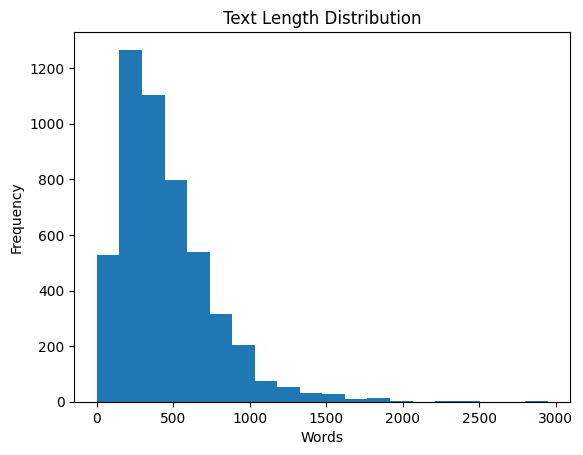

In [33]:
text_length = text_df["cleaned_text"].apply(
    lambda x: len(x.split())
)

plt.hist(text_length, bins=20)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Text Length Distribution")
plt.show()

In [35]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("chest_xray.jpeg")

print("Original size:", image.size)

Original size: (1857, 1317)


In [37]:
image = image.convert("L")
image = image.resize((224, 224))

image_array = np.array(image)

image_normalized = image_array / 255.0

image_tensor = np.expand_dims(
    image_normalized,
    axis=-1
)

print("Tensor shape:", image_tensor.shape)

Tensor shape: (224, 224, 1)


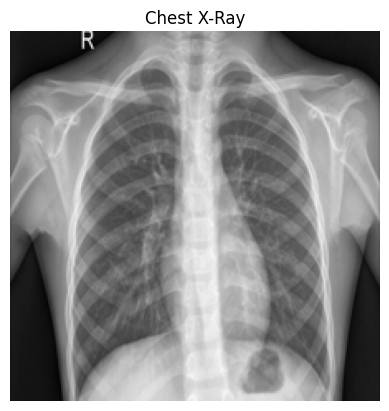

In [38]:
plt.imshow(image_normalized, cmap="gray")
plt.axis("off")
plt.title("Chest X-Ray")
plt.show()

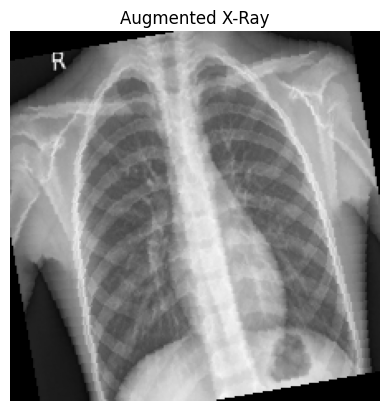

In [39]:
augmented_image = image.rotate(10)

plt.imshow(augmented_image, cmap="gray")
plt.axis("off")
plt.title("Augmented X-Ray")
plt.show()

In [40]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.2 MB/s eta 0:00:00


In [41]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

signal = record.p_signal[:, 0]

print("Signal length:", len(signal))
print("Sampling frequency:", record.fs)

Signal length: 650000
Sampling frequency: 360


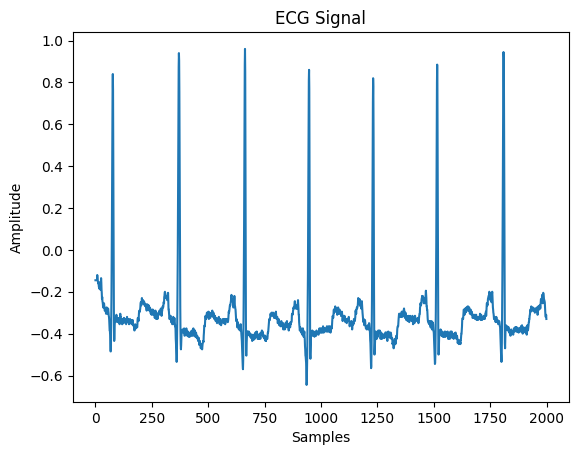

In [42]:
plt.plot(signal[:2000])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("ECG Signal")
plt.show()

In [43]:
window_size = 5

kernel = np.ones(window_size) / window_size

filtered_signal = np.convolve(
    signal,
    kernel,
    mode="same"
)

In [44]:
window_length = 180

windows = []

for i in range(
    0,
    len(filtered_signal) - window_length,
    window_length
):
    windows.append(
        filtered_signal[i:i + window_length]
    )

windows = np.array(windows)

print("Signal windows shape:", windows.shape)

Signal windows shape: (3611, 180)


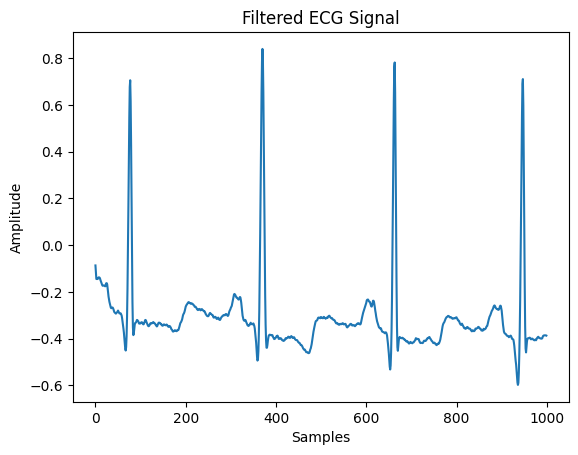

In [45]:
plt.plot(filtered_signal[:1000])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("Filtered ECG Signal")
plt.show()